# 01 — Data quality & loading
**AccessMap London** · TfL Station Accessibility Gap Analysis

**Goal:** Understand every raw table before touching anything — nulls, types, duplicates, value distributions.

> Put your 11 TfL CSVs in `raw_data/` then run all cells top to bottom.


## Setup — imports
*Run this first every time.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 130, 'figure.figsize': (12, 5)})

COLOURS = {
    'Good (70-100)':   '#1D9E75',
    'Partial (40-69)': '#EF9F27',
    'Poor (0-39)':     '#E24B4A',
}
BAND_ORDER = ['Good (70-100)', 'Partial (40-69)', 'Poor (0-39)']
PALETTE    = [COLOURS[b] for b in BAND_ORDER]

print('Libraries loaded ✓')

Libraries loaded ✓


## Load raw data
*Reads directly from `raw_data/` — no pre-processing.*

In [2]:
RAW = '../raw_data/'

stations     = pd.read_csv(RAW + 'Stations.csv')
lifts        = pd.read_csv(RAW + 'Lifts.csv')
platforms    = pd.read_csv(RAW + 'Platforms.csv')
platform_svc = pd.read_csv(RAW + 'PlatformServices.csv')
toilets      = pd.read_csv(RAW + 'Toilets.csv')
stn_points   = pd.read_csv(RAW + 'StationPoints.csv')
step_free    = pd.read_csv(RAW + 'StepFreeIntechangeInfo.csv')
ramp_routes  = pd.read_csv(RAW + 'RampRoutes.csv')
modes_lines  = pd.read_csv(RAW + 'ModesAndLines.csv')
feed_info    = pd.read_csv(RAW + 'FeedInfo.csv')

print('All raw files loaded ✓')
print(f'  Stations        : {len(stations):>4} rows')
print(f'  Lifts           : {len(lifts):>4} rows')
print(f'  Platforms       : {len(platforms):>4} rows')
print(f'  PlatformServices: {len(platform_svc):>4} rows')
print(f'  Toilets         : {len(toilets):>4} rows')
print(f'  StationPoints   : {len(stn_points):>4} rows')
print(f'  StepFreeInfo    : {len(step_free):>4} rows')
print(f'  RampRoutes      : {len(ramp_routes):>4} rows')

All raw files loaded ✓
  Stations        :  509 rows
  Lifts           :  569 rows
  Platforms       : 1584 rows
  PlatformServices: 1878 rows
  Toilets         :  410 rows
  StationPoints   : 4084 rows
  StepFreeInfo    :  114 rows
  RampRoutes      :  418 rows


## Clean data
*Fix boolean types, extract primary zone, normalise fields.*

In [3]:
def to_bool(s):
    return (s.astype(str).str.strip().str.upper()
             .map({'TRUE': True, 'FALSE': False, '1': True, '0': False, 'NAN': False})
             .fillna(False))

# Stations
st = stations.copy()
for col in ['Wifi','BlueBadgeCarParking','TaxiRanksOutsideStation',
            'MainBusInterchange','NationalRailInterchange','AirportInterchange']:
    if col in st.columns:
        st[col] = to_bool(st[col])
st['PrimaryZone'] = st['FareZones'].astype(str).str.extract(r'(\d)')[0].fillna('Unknown')

# Lifts
lf = lifts.copy()
lf['LimitedCapacityLift'] = to_bool(lf['LimitedCapacityLift'])

# Platforms
pl = platforms.copy()
pl['HasStepFreeRouteInformation'] = to_bool(pl['HasStepFreeRouteInformation'])

# PlatformServices
ps = platform_svc.copy()
ps['DesignatedLevelAccessPoint'] = to_bool(ps['DesignatedLevelAccessPoint'])
ps['LevelAccessByManualRamp']    = to_bool(ps['LevelAccessByManualRamp'])

# Toilets
tl = toilets.copy()
for col in ['IsAccessible','HasBabyChanging','IsInsideGateLine','IsFeeCharged','IsManagedByTfL']:
    tl[col] = to_bool(tl[col])

# Step-free — extract station prefix
sf = step_free.copy()
sf['FromStation'] = sf['FromPlatformUniqueId'].str.extract(r'^([^-]+-[^-]+)')

# Geo coords
geo = (stn_points.groupby('StationUniqueId')
                  .agg(Lat=('Lat','mean'), Lon=('Lon','mean'))
                  .reset_index()
                  .rename(columns={'StationUniqueId':'UniqueId'}))

print('Cleaning done ✓')

Cleaning done ✓


## Feature engineering
*Aggregate per station and compute the accessibility score.*

In [4]:
# Lift counts per station
lift_agg = (lf.groupby('StationUniqueId')
              .agg(TotalLifts=('LiftUniqueId','count'),
                   LimitedCapacityLifts=('LimitedCapacityLift','sum'))
              .reset_index())

# Step-free platforms per station
plat_agg = (pl.groupby('StationUniqueId')
              .agg(TotalPlatforms=('UniqueId','count'),
                   PlatformsWithStepFree=('HasStepFreeRouteInformation','sum'))
              .reset_index())
plat_agg['StepFreePlatformPct'] = (plat_agg['PlatformsWithStepFree'] / plat_agg['TotalPlatforms']).round(3)

# Step-free interchange per station
sf_agg = (sf.groupby('FromStation')
            .agg(AvgInterchangeDistM=('DistanceInMetres','mean'),
                 MaxInterchangeDistM=('DistanceInMetres','max'),
                 StepFreeInterchangeCount=('FromPlatformUniqueId','count'))
            .reset_index()
            .rename(columns={'FromStation':'UniqueId'}))

# Toilet counts per station
toilet_agg = (tl.groupby('StationUniqueId')
                .agg(TotalToilets=('Id','count'),
                     AccessibleToilets=('IsAccessible','sum'),
                     HasBabyChanging=('HasBabyChanging','any'),
                     FreeToilets=('IsFeeCharged', lambda x: (~x).sum()))
                .reset_index()
                .rename(columns={'StationUniqueId':'UniqueId'}))

# Level access per station
plat_map = pl[['UniqueId','StationUniqueId']].rename(columns={'UniqueId':'PlatformUniqueId'})
ps_st    = ps.merge(plat_map, on='PlatformUniqueId', how='left')
ps_agg   = (ps_st.groupby('StationUniqueId')
                  .agg(TotalPlatformSvc=('PlatformUniqueId','count'),
                       LevelAccessPlatforms=('DesignatedLevelAccessPoint','sum'),
                       RampAccessPlatforms=('LevelAccessByManualRamp','sum'))
                  .reset_index()
                  .rename(columns={'StationUniqueId':'UniqueId'}))
ps_agg['LevelAccessPct'] = (ps_agg['LevelAccessPlatforms'] / ps_agg['TotalPlatformSvc']).round(3)

# Lines served per station
lines_agg = (ps_st.groupby('StationUniqueId')['Line']
                   .apply(lambda x: ', '.join(sorted(x.dropna().unique())))
                   .reset_index()
                   .rename(columns={'StationUniqueId':'UniqueId','Line':'LinesServed'}))

# Ramp routes per station
rr = ramp_routes.copy()
rr['StationId'] = rr['From'].str.extract(r'^([^-]+-[^-]+)')
ramp_agg = (rr.groupby('StationId').size()
              .reset_index(name='RampRouteCount')
              .rename(columns={'StationId':'UniqueId'}))

# Assemble master table
master = st.copy()
for right, rkey, lkey in [
    (lift_agg,   'StationUniqueId', 'UniqueId'),
    (plat_agg,   'StationUniqueId', 'UniqueId'),
    (sf_agg,     'UniqueId',        'UniqueId'),
    (toilet_agg, 'UniqueId',        'UniqueId'),
    (ps_agg,     'UniqueId',        'UniqueId'),
    (lines_agg,  'UniqueId',        'UniqueId'),
    (ramp_agg,   'UniqueId',        'UniqueId'),
    (geo,        'UniqueId',        'UniqueId'),
]:
    master = master.merge(right, left_on=lkey, right_on=rkey, how='left')
    if rkey != lkey and rkey in master.columns:
        master.drop(columns=[rkey], inplace=True, errors='ignore')

# Fill missing
count_cols = ['TotalLifts','LimitedCapacityLifts','TotalPlatforms','PlatformsWithStepFree',
              'TotalToilets','AccessibleToilets','FreeToilets','TotalPlatformSvc',
              'LevelAccessPlatforms','RampAccessPlatforms','RampRouteCount','StepFreeInterchangeCount']
for col in count_cols:
    if col in master.columns:
        master[col] = master[col].fillna(0).astype(int)
for col in ['StepFreePlatformPct','LevelAccessPct']:
    if col in master.columns:
        master[col] = master[col].fillna(0)

# Accessibility score (0–100)
master['HasLift']             = (master['TotalLifts'] > 0).astype(int)
master['HasAccessibleToilet'] = (master['AccessibleToilets'] > 0).astype(int)
master['HasRamp']             = (master['RampRouteCount'] > 0).astype(int)

master['AccessibilityScore'] = (
    master['HasLift']             * 30 +
    master['StepFreePlatformPct'] * 25 +
    master['HasAccessibleToilet'] * 20 +
    master['LevelAccessPct']      * 15 +
    master['HasRamp']             * 10
).round(1)

master['AccessibilityBand'] = master['AccessibilityScore'].apply(
    lambda s: 'Good (70-100)' if s >= 70 else ('Partial (40-69)' if s >= 40 else 'Poor (0-39)')
)

print(f'Master table ready: {master.shape}')
print(master['AccessibilityBand'].value_counts())

Master table ready: (509, 40)
AccessibilityBand
Poor (0-39)        247
Partial (40-69)    172
Good (70-100)       90
Name: count, dtype: int64


---
## Data quality checks

In [5]:
# ── Feed info — when was this data published? ───────────────────
print('=== Feed info ===')
print(feed_info.to_string(index=False))

=== Feed info ===
   FeedPublisherName   FeedPublisherUrl FeedLang          FeedStartDate
Transport for London https://tfl.gov.uk       en 2026-06-16T13:45+00:00


In [6]:
# ── Table inventory ─────────────────────────────────────────────
tables = {
    'Stations': stations, 'Lifts': lifts, 'Platforms': platforms,
    'PlatformServices': platform_svc, 'Toilets': toilets,
    'StationPoints': stn_points, 'StepFreeInterchange': step_free,
    'RampRoutes': ramp_routes, 'ModesAndLines': modes_lines,
}
summary = pd.DataFrame([
    {'Table': name, 'Rows': df.shape[0], 'Columns': df.shape[1],
     'Columns list': ', '.join(df.columns[:6]) + ('...' if len(df.columns)>6 else '')}
    for name, df in tables.items()
])
print(summary.to_string(index=False))

              Table  Rows  Columns                                                                                      Columns list
           Stations   509       14                         UniqueId, Name, FareZones, HubNaptanCode, Wifi, OutsideStationUniqueId...
              Lifts   569       12                StationUniqueId, LiftUniqueId, LiftId, NationalRailUprn, LiftName, FriendlyName...
          Platforms  1584       10 UniqueId, StationUniqueId, PlatformNumber, CardinalDirection, PlatformNaptanCode, FriendlyName...
   PlatformServices  1878       15                   PlatformUniqueId, StopAreaNaptanCode, Line, DirectionTowards, MinGap, MaxGap...
            Toilets   410       46                              Station, StationUniqueId, Id, Type, IsAccessible, HasBabyChanging...
      StationPoints  4084        8                                        UniqueId, StationUniqueId, AreaName, AreaId, Level, Lat...
StepFreeInterchange   114        3                                   

In [7]:
# ── Preview every table ─────────────────────────────────────────
for name, df in tables.items():
    print(f'\n{"="*55}  {name}')
    display(df.head(3))


=======================================================  Stations


,UniqueId,Name,FareZones,HubNaptanCode,Wifi,OutsideStationUniqueId,BlueBadgeCarParking,BlueBadgeCarParkSpaces,TaxiRanksOutsideStation,MainBusInterchange,PierInterchange,NationalRailInterchange,AirportInterchange,EmiratesAirLineInterchange
0,HUBABW,Abbey Wood,4,HUBABW,False,HUBABW-Outside,False,NaN,False,NaN,NaN,NaN,NaN,NaN
1,910GACTNCTL,Acton Central,3,NaN,True,910GACTNCTL-Outside,False,NaN,False,NaN,NaN,NaN,NaN,NaN
2,910GACTONML,Acton Main Line,3,NaN,False,910GACTONML-Outside,False,NaN,False,NaN,NaN,NaN,NaN,NaN



=======================================================  Lifts


,StationUniqueId,LiftUniqueId,LiftId,NationalRailUprn,LiftName,FriendlyName,FromAreas,IntermediateAreas,IntermediateAreas2,ToAreas,LimitedCapacityLift,LiftNotes
0,910GACTONML,910GACTONML-Lift-1,1,NaN,NaN,Lift A,910GACTONML-1001003-AC-S-6,NaN,NaN,910GACTONML-1001003-RPL1-2,False,NaN
1,910GACTONML,910GACTONML-Lift-2,2,NaN,NaN,Lift B,910GACTONML-1001003-AC-S-6,NaN,NaN,910GACTONML-1001003-RPL2-5,False,NaN
2,910GBRENTX,910GBRENTX-Lift-1,1,NaN,NaN,Lift 1,910GBRENTX-1002310-EntW-7,NaN,NaN,910GBRENTX-1002310-FB-8,False,NaN



=======================================================  Platforms


...

,FromPlatformUniqueId,ToPlatformUniqueId,DistanceInMetres
0,910GACTNCTL-Plat01-WB-london-overground,910GACTNCTL-Plat02-EB-london-overground,50
1,910GACTNCTL-Plat02-EB-london-overground,910GACTNCTL-Plat01-WB-london-overground,50
2,910GANERLEY-Plat01-NB-london-overground|nation...,910GANERLEY-Plat02-SB-london-overground|nation...,220



=======================================================  RampRoutes


,From,To
0,910GACTNCTL-1001002-AC-3,910GACTNCTL-1001002-RLY-4
1,910GACTNCTL-1001002-ENTR-7,910GACTNCTL-1001002-RPL-5
2,910GACTNCTL-1001002-RLY-4,910GACTNCTL-1001002-AC-3



=======================================================  ModesAndLines


,Mode,Name
0,cableCar,london-cable-car
1,dlr,dlr
2,nationalRail,thameslink


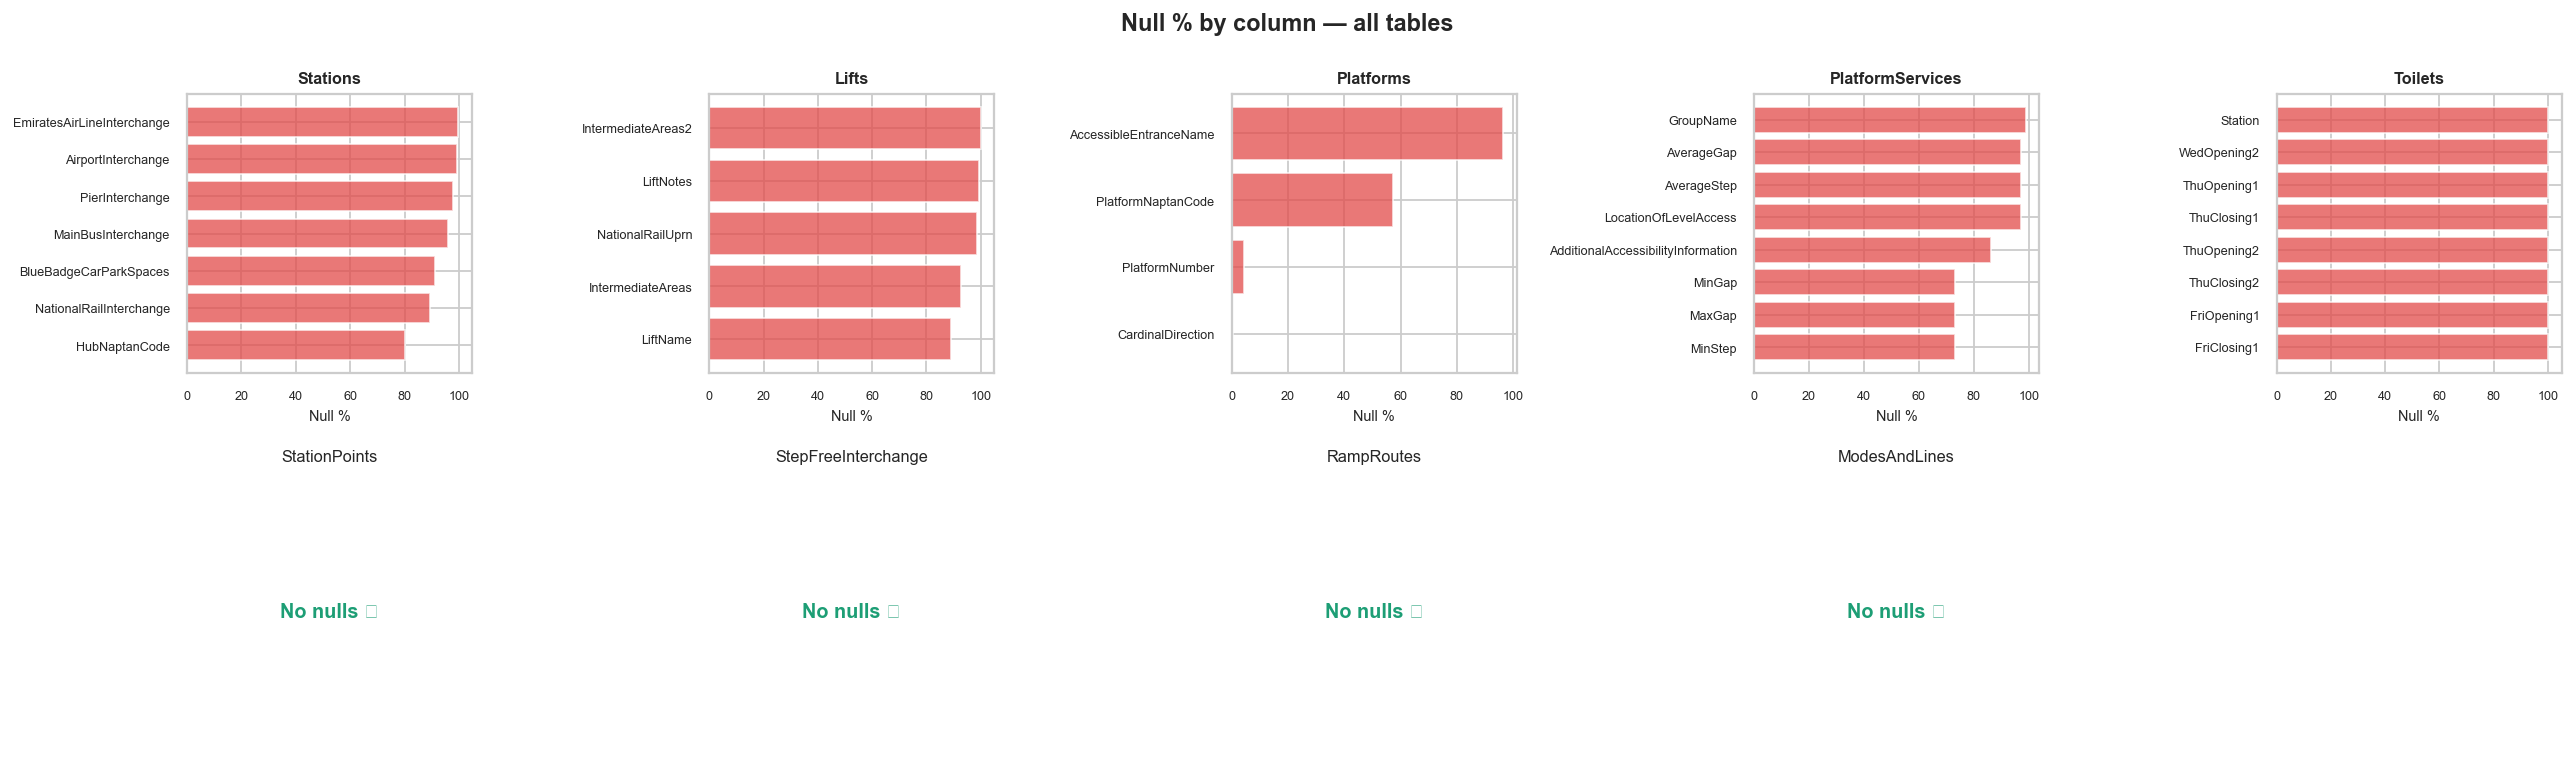

In [8]:
# ── Null % heatmap across all tables ────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(20, 6))
axes = axes.flatten()
for i, (name, df) in enumerate(tables.items()):
    null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
    null_pct = null_pct[null_pct > 0].head(8)
    if len(null_pct):
        axes[i].barh(null_pct.index, null_pct.values, color='#E24B4A', alpha=0.75)
        axes[i].set_title(name, fontsize=9, fontweight='bold')
        axes[i].set_xlabel('Null %', fontsize=8)
        axes[i].tick_params(labelsize=7)
        axes[i].invert_yaxis()
    else:
        axes[i].text(0.5, 0.5, 'No nulls ✓', ha='center', va='center',
                     color='#1D9E75', fontsize=11, fontweight='bold')
        axes[i].set_title(name, fontsize=9)
        axes[i].axis('off')
for j in range(i+1, len(axes)): axes[j].axis('off')
plt.suptitle('Null % by column — all tables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# ── Boolean consistency check ───────────────────────────────────
print('Stations — boolean columns unique values:')
for col in ['Wifi','BlueBadgeCarParking','MainBusInterchange','NationalRailInterchange']:
    if col in stations.columns:
        print(f'  {col:35s}: {stations[col].unique()}')

print('\nToilets — IsAccessible unique values:')
print(' ', toilets['IsAccessible'].unique())

print('\nPlatforms — HasStepFreeRouteInformation unique values:')
print(' ', platforms['HasStepFreeRouteInformation'].unique())

Stations — boolean columns unique values:
  Wifi                               : [False  True]
  BlueBadgeCarParking                : [False  True]
  MainBusInterchange                 : [nan 'Full']
  NationalRailInterchange            : [nan 'Partial']

Toilets — IsAccessible unique values:
  ['TRUE' 'FALSE' '    TRUE ']

Platforms — HasStepFreeRouteInformation unique values:
  ['TRUE' 'FALSE' 'FALSE ']


In [10]:
# ── Duplicate check ─────────────────────────────────────────────
print('Duplicate row check:')
for name, df in tables.items():
    dupes = df.duplicated().sum()
    print(f'  {name:25s}: {"✓ no duplicates" if dupes==0 else f"⚠ {dupes} duplicates"}')

print(f'\nStations UniqueId — unique? '
      f'{stations["UniqueId"].nunique()} unique / {len(stations)} total')

Duplicate row check:
  Stations                 : ✓ no duplicates
  Lifts                    : ✓ no duplicates
  Platforms                : ✓ no duplicates
  PlatformServices         : ✓ no duplicates
  Toilets                  : ✓ no duplicates
  StationPoints            : ✓ no duplicates
  StepFreeInterchange      : ⚠ 12 duplicates
  RampRoutes               : ✓ no duplicates
  ModesAndLines            : ✓ no duplicates

Stations UniqueId — unique? 509 unique / 509 total


In [11]:
# ── Fare zone distribution ──────────────────────────────────────
print('FareZones value counts (top 15):')
print(stations['FareZones'].value_counts().head(15))

print('\nModes & Lines:')
print(modes_lines)

FareZones value counts (top 15):
FareZones
2                    113
3                     80
4                     72
1                     64
5                     37
Trams fare zone       32
6                     32
2|3                   27
Outside               12
3|4                   10
1|2                    6
7                      6
8                      6
4|Trams fare zone      4
9                      3
Name: count, dtype: int64

Modes & Lines:
              Mode              Name
0         cableCar  london-cable-car
1              dlr               dlr
2     nationalRail        thameslink
3     nationalRail     national-rail
4       overground           liberty
5       overground           lioness
6       overground           mildmay
7       overground       suffragette
8       overground            weaver
9       overground          windrush
10  elizabeth-line         elizabeth
11            tram              tram
12            tube          bakerloo
13            tube    